In [ ]:
!pip install pandas numpy xgboost shap matplotlib scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [ ]:
data = pd.read_csv("/content/synthetic_aqi_data_with_pollutants.csv")

print(data.head())
print(data.info())

   Temperature   Humidity  WindSpeed        NO2        SO2         CO  \
0    22.490802  34.810634   5.234114  67.270299  57.199588  39.363552   
1    34.014286  63.352076   4.939576  79.668140  80.543233  47.343566   
2    29.639879  89.835667  18.125092  25.046790  76.016093  85.454739   
3    26.973170  78.577991   4.990924  62.487410  15.389990  34.000439   
4    18.120373  84.524892   5.438995  57.174598  14.924947  86.964968   

          O3         PM        AQI  
0  64.825695   3.879945  52.978213  
1  17.238636  18.677253  67.102748  
2  87.239456  83.124581  66.798514  
3  61.311624  76.676836  66.312769  
4  15.720388  35.064269  54.381166  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  1000 non-null   float64
 1   Humidity     1000 non-null   float64
 2   WindSpeed    1000 non-null   float64
 3   NO2          1000 n

In [ ]:
features = ['Temperature', 'Humidity', 'WindSpeed', 'NO2', 'SO2','CO','O3','PM']
target = 'AQI'
X = data[features]
y = data[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor()
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
y_pred = model.predict(X_test)
print("predictions: ",y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")

predictions:  [66.92101  44.15038  72.66027  58.255856 28.385052 60.398067 46.18316
 65.59217  64.994705 74.96191  67.1629   61.144558 64.72917  63.783916
 42.73798  75.87359  67.19273  59.77811  66.40453  54.1715   59.510338
 47.577263 53.453953 64.07885  49.047195 46.026375 70.721344 56.579685
 52.840885 52.114456 36.91936  61.911007 47.790344 77.35147  59.534706
 57.697853 52.047703 65.65356  42.492577 75.32606  44.19471  59.276943
 57.955482 42.54686  61.853996 58.313694 60.43473  48.74755  62.78776
 46.93088  58.61593  44.338528 73.360085 71.64662  59.850826 42.658943
 66.36341  38.28553  43.516003 48.802666 44.383846 75.495674 60.51668
 59.25659  39.606884 53.92295  59.089462 45.36084  56.12365  60.24532
 44.465027 53.184437 63.802788 54.44039  49.950626 51.597244 46.006107
 57.887363 64.386505 52.499138 54.53212  24.40327  55.75067  56.272793
 49.86285  40.210247 59.95812  60.017956 53.43124  63.774357 51.289177
 62.96838  58.011692 65.464134 72.26244  37.403145 51.767452 69.245

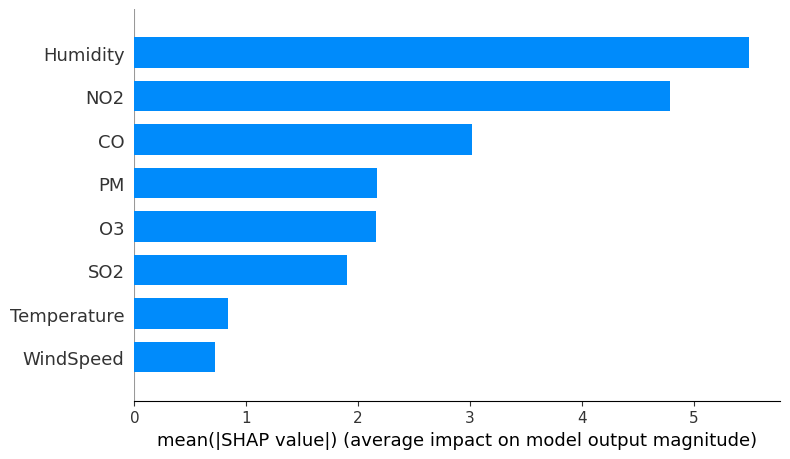

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
sample_instance = X_test.iloc[0]
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], sample_instance)


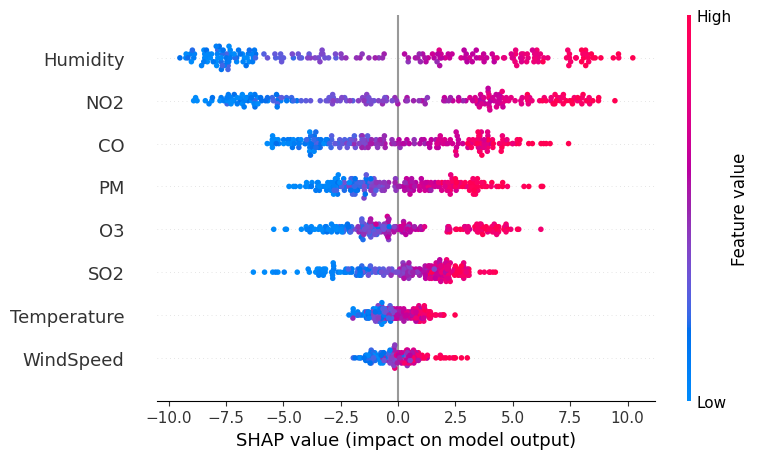

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="dot")

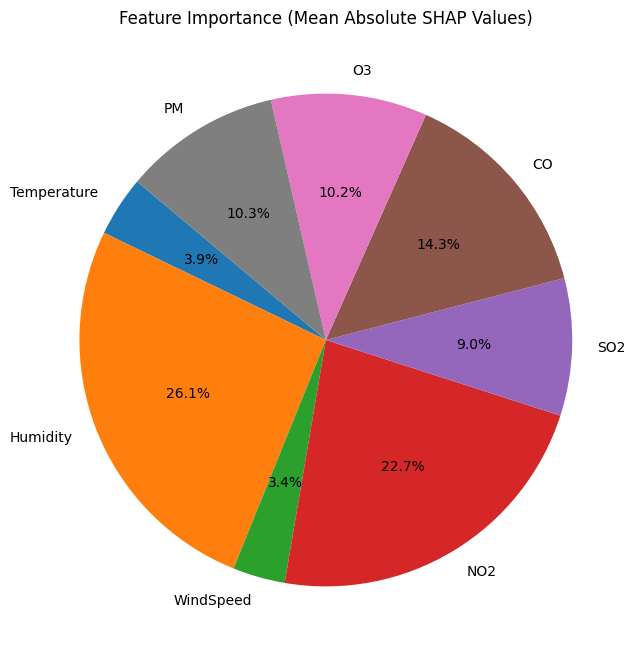

In [ ]:
mean_shap_values = np.abs(shap_values).mean(axis=0)

plt.figure(figsize=(8, 8))
plt.pie(mean_shap_values, labels=X_test.columns, autopct='%1.1f%%', startangle=140)
plt.title("Feature Importance (Mean Absolute SHAP Values)")
plt.show()
